# **Machine Learning for Human Data Final Project**

**A3: Motor Imagery Classification from EEG for Brain–Computer Interface**

**Authors**: Bianciardi Tommaso, Zanovello Marco

**Project Overview:**
This project focuses on the development of a robust pipeline for decoding motor imagery (MI) from electroencephalographic (EEG) signals using the **Kaya et al. (2018) dataset**. Motor imagery classification is a fundamental challenge in the field of Brain–Computer Interfaces (BCI), where the goal is to translate neural intent into actionable commands.

**Technical Workflow**

Our approach follows a structured, modular pipeline designed to handle raw signal acquisition through to high-level model evaluation. 
As illustrated in the project scheme, our workflow consists of four primary phases:


1. Phase 1 (Signal Processing): Data ingestion followed by rigorous noise reduction. We apply a 50Hz notch filter to remove power line interference and a 8-30Hz bandpass filter to focus on relevant frequency bands. We further enhance signal quality using Common Average Reference (CAR).
2. Phase 2 (Segmentation & Formatting): We epoch the continuous signal from $t_0+0.5s$ to $t_0+3.5s$ to isolate motor imagery intervals while avoiding initial visual-evoked potentials. This phase includes artifact rejection (thresholding at $100 \mu V$), normalization, and final tensor construction.
3. Phase 3 (Modeling): We implement a comparative analysis between established benchmarks like EEGNet and our proposed Multiscale Inception CNN architecture to effectively capture complex temporal-spatial patterns.
4. Phase 4 (Evaluation): The performance of our models is rigorously assessed using accuracy, confusion matrices, and the Cohen's Kappa score to ensure robust classification.


# **Phase 1: Data Ingestion and Filtering**

**Workflow Overview:**
1.  **Data Ingestion:** Loading `.mat` files containing raw EEG data and marker timestamps.
2.  **Signal Processing:**
    *  Filtering (Notch 50Hz, Bandpass 8-30Hz).
    * Common Average Reference (CAR).


Import of libraries and set global variables:

In [1]:
import os
import glob
import random
import time
import re as _re
import numpy as np
import pandas as pd
import scipy.io
from scipy.signal import butter, filtfilt, welch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
from sklearn.manifold import TSNE
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, DepthwiseConv2D, AveragePooling2D, Dropout, SeparableConv2D, Flatten, Dense, Activation, Concatenate
from tensorflow.keras.regularizers import l2
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.callbacks import EarlyStopping
import collections


# Define a single seed value
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# Path to the dataset directory 
DATASET_PATH = '/kaggle/input/datasets/tommasobianciardi/motor-imagery-classification/data'

# Epoching Configuration
# Skip first 0.5s (visual reaction) and take 3 seconds of data
WINDOW_S = (0.5, 3.5) 

# Artifact Rejection Threshold
THRESHOLD_UV = 100  # Discard epochs with amplitude > 100 uV

print(f"Configuration Set: Window={WINDOW_S}s, Threshold={THRESHOLD_UV}uV (FS extracted per file)")

2026-07-02 16:30:06.431607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783009806.614868      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783009806.668199      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783009807.140378      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783009807.140417      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783009807.140420      58 computation_placer.cc:177] computation placer alr

Configuration Set: Window=(0.5, 3.5)s, Threshold=100uV (FS extracted per file)


## Data Ingestion: Loading the Kaya 2018 Dataset

This function handles the extraction of raw EEG signals and synchronization markers from the dataset's .mat file structure. It isolates the primary 19 scalp channels to focus on relevant brain activity according to the standard 10/20 electrode placement system

In [2]:
def load_kaya_mat(file_path):
    """
    Loads raw EEG data and markers from the Kaya 2018 .mat files.
    
    Args:
        file_path (str): Path to the .mat file.
        
    Returns:
        eeg_channels (np.array): Shape (n_samples, 19). Contains channels Fp1...Pz.
        marker (np.array): Shape (n_samples,). Sync markers (0=Idle, 1-6=Stimulus).
        sfreq (int): Sampling frequency.
    """
    mat = scipy.io.loadmat(file_path)
    # Access the struct 'o'
    o_struct = mat['o'][0,0]
    
    # Extract data and flatten markers
    data = o_struct['data']
    marker = o_struct['marker'].flatten() 
    sfreq = int(o_struct['sampFreq'].flat[0])
    
    # Keep only the first 19 EEG channels (Standard 10/20 system)
    # Columns 19-21 are Ground (A1, A2) and Sync (X3) 
    eeg_channels = data[:, :19] 
    
    return eeg_channels, marker, sfreq
    
# An example:
file_path = '/kaggle/input/datasets/tommasobianciardi/motor-imagery-classification/data/CLA-SubjectA-160108-3St-LRHand.mat'
eeg, triggers, fs = load_kaya_mat(file_path)
print(f"Shape EEG: {eeg.shape}, Freq: {fs}Hz")

Shape EEG: (671600, 19), Freq: 200Hz


## Signal Preprocessing (Filtering)

To enhance the signal-to-noise ratio and isolate the relevant neural oscillations for motor imagery, we apply a two-stage filtering process. First, a notch filter removes 50Hz power line interference, followed by a bandpass filter that focuses on the mu ($8-13 \text{ Hz}$) and beta ($14-30 \text{ Hz}$) rhythms, which are key indicators of motor intent.

In [3]:
def apply_filters(eeg_data, fs):
    """
    Applies Block A filters: Notch (50Hz) and Bandpass (8-30Hz) for Motor Imagery.
    
    Args:
        eeg_data (np.ndarray): EEG signal with shape (n_samples, n_channels).
        fs (int): Sampling frequency in Hz.
        
    Returns:
        eeg_filtered (np.ndarray): Filtered EEG signal with shape (n_samples, n_channels).
    """
    # Notch Filter (50Hz) to remove power line noise
    b_notch, a_notch = butter(N=4, Wn=[49, 51], btype='bandstop', fs=fs)
    eeg_notch = filtfilt(b_notch, a_notch, eeg_data, axis=0)
    
    # Bandpass Filter (8 -30Hz)
    b_band, a_band = butter(N=4, Wn=[8, 30], btype='bandpass', fs=fs)
    eeg_filtered = filtfilt(b_band, a_band, eeg_notch, axis=0)
    
    return eeg_filtered

## Signal Preprocessing (Common Average Reference)

To further reduce common-mode noise and artifacts that affect all EEG channels simultaneously, we apply a Common Average Reference (CAR). This technique involves calculating the spatial average of all electrodes at each time point and subtracting it from each individual channel, effectively "referencing" the signal to the global activity of the scalp.

In [4]:
def apply_car(eeg_data):
    """
    Applies Block B: Common Average Reference (CAR).
    Subtracts the mean of all channels from each channel.
    
    Args:
        eeg_data (np.ndarray): EEG signal with shape (n_samples, n_channels).
        
    Returns:
        eeg_car (np.ndarray): Signal after CAR, with shape (n_samples, n_channels).
    """
    average = np.mean(eeg_data, axis=1, keepdims=True)
    eeg_car = eeg_data - average
    return eeg_car

# **Phase 2: Epoching, Segmentation, and Formatting**

In this phase, we transition from continuous EEG signals to discrete trials suitable for deep learning. We segment the data into specific intervals, filter out artifacts, and organize the trials into a structured tensor format.

**Workflow Overview**:
1. Segmentation: Extracts trials from $t_0+0.5\text{s}$ to $t_0+3.5\text{s}$ to isolate motor imagery while avoiding initial visual-evoked potentials.
2. Label Assignment: Maps triggers to specific motor movement classes.
3. Artifact Rejection: Filters out trials exceeding the amplitude threshold ($100 \mu V$).
4. Dataset Splitting: Segments the data into training, validation and testing sets.
5. Normalization: Scales the data to ensure stable model convergence.

**Output**: A structured final tensor with shape $(N_{samples}, \text{Channels}, \text{Time}_{\text{points}})$

## Segmentation (Epoching)

This function translates the continuous EEG stream into discrete, labeled segments corresponding to motor imagery events. It identifies the precise onset of each trial, applies the specified time window, and formats the result into a $(N_{\text{epochs}}, \text{Channels}, \text{Time}_{\text{points}})$ structure, which is the standard input format for deep learning architectures.

In [5]:
def create_epochs(eeg_data, markers, fs, window_s):
    """
    Segments continuous data into epochs based on markers.
    
    Args:
        eeg_data (np.ndarray): Continuous EEG signal, shape (n_samples, n_channels).
        markers (np.ndarray): Event markers, shape (n_samples,).
        fs (int): Sampling frequency in Hz.
        window_s (tuple): Time window (start_sec, end_sec) relative to onset.
        
    Returns:
        epochs (np.ndarray): Segmented data, shape (n_epochs, n_channels, n_time_points).
        labels (np.ndarray): Labels corresponding to each epoch.
    """
    # Detect onset: where marker changes from 0 to >0 
    diff_markers = np.diff(markers, prepend=0)
    onset_indices = np.where((markers > 0) & (diff_markers != 0))[0]
    
    epochs = []
    labels = []
    
    start_sample = int(window_s[0] * fs)
    end_sample = int(window_s[1] * fs)
    
    for idx in onset_indices:
        code = markers[idx]
        
        # Ignore service codes (99: relaxation, 91: break, 92: end) 
        if code > 10: 
            continue
            
        t_start = idx + start_sample
        t_end = idx + end_sample
        
        # Ensure the epoch falls within the recording duration
        if t_end <= eeg_data.shape[0]:
            epoch = eeg_data[t_start:t_end, :]
            # Transpose to (Channels, Time) for standard DL format
            epochs.append(epoch.T) 
            labels.append(code)
            
    return np.array(epochs), np.array(labels)

## Data Aggregation and Artifact Rejection

This block executes the core pipeline loop. It systematically iterates through the dataset to ingest, filter, reference, and segment the EEG trials. It also implements an artifact rejection step, discarding any trials that exceed the $100 \mu V$ threshold, ensuring that only high-quality neural data is retained for training. 

Finally, it aggregates the data into a subject-based dictionary for streamlined model access.

In [6]:
epoch_bank = {}
subject_paradigms = collections.defaultdict(set)

file_list = glob.glob(os.path.join(DATASET_PATH, '*.mat'))
print(f"Total files found: {len(file_list)}")

for file_path in file_list:
    filename = os.path.basename(file_path)

    if not (filename.startswith('CLA') or filename.startswith('HaLT')):
        continue
    if 'HFREQ' in filename or 'Inter' in filename:
        continue

    # Determine paradigm from filename
    if filename.startswith('CLA'):
        paradigm = 'CLA'
    elif filename.startswith('HaLT'):
        paradigm = 'HaLT'
    else:
        paradigm = 'UNKNOWN'

    match = _re.search(r'Subject([A-Z])', filename)
    if not match:
        print(f"  [SKIP] Cannot parse subject ID from: {filename}")
        continue

    subject_id = match.group(1)

    # Record which paradigm(s) this subject belongs to
    subject_paradigms[subject_id].add(paradigm)

    try:
        eeg, markers, fs = load_kaya_mat(file_path)
        eeg = apply_filters(eeg, fs)
        eeg = apply_car(eeg)

        epochs, labels = create_epochs(eeg, markers, fs, WINDOW_S)
        if len(epochs) == 0:
            continue

        # Artifact Rejection
        mask = np.max(np.abs(epochs), axis=(1, 2)) <= THRESHOLD_UV
        epochs_clean = epochs[mask]
        labels_clean = labels[mask]
        if len(epochs_clean) == 0:
            continue

        # Keep only Left Hand, Right Hand and Passive
        mask_classes = np.isin(labels_clean, [1, 2, 3])
        epochs_clean = epochs_clean[mask_classes]
        labels_clean = labels_clean[mask_classes]
        if len(epochs_clean) == 0:
            continue

        if subject_id not in epoch_bank:
            epoch_bank[subject_id] = {'epochs': [], 'labels': []}

        epoch_bank[subject_id]['epochs'].append(epochs_clean)
        epoch_bank[subject_id]['labels'].append(labels_clean)

    except Exception as e:
        print(f"  [ERROR] {filename}: {e}")


# Combine all recordings for each subject

subject_data = {}
for sid, data in epoch_bank.items():
    subject_data[sid] = {
        'X': np.concatenate(data['epochs'], axis=0),
        'y': np.concatenate(data['labels'], axis=0),
    }

all_subjects = sorted(subject_data.keys())

print(f"\n{'─'*78}")
print("  PIPELINE COMPLETE")
print(f"{'─'*78}")
print(f"  Subjects loaded: {len(all_subjects)} → {all_subjects}")
print(f"{'─'*78}")

print(f"  {'Subject':<8} {'Paradigm':<12} {'Total':>7} {'LH':>6} {'RH':>6} {'Passive':>8}")
print(f"  {'─'*7:<8} {'─'*9:<12} {'─'*5:>7} {'─'*4:>6} {'─'*4:>6} {'─'*6:>8}")

for sid in all_subjects:
    unique, counts = np.unique(subject_data[sid]['y'], return_counts=True)
    dist = {int(k): int(v) for k, v in zip(unique, counts)}

    total = subject_data[sid]['X'].shape[0]
    lh = dist.get(1, 0)
    rh = dist.get(2, 0)
    passive = dist.get(3, 0)

    paradigm = "+".join(sorted(subject_paradigms[sid]))

    print(f"  {sid:<8} {paradigm:<12} {total:>7} {lh:>6} {rh:>6} {passive:>8}")

print(f"{'─'*78}")
total_all = sum(subject_data[s]['X'].shape[0] for s in all_subjects)
print(f"  {'TOTAL':<21} {total_all:>7}")
print(f"{'─'*78}")


# Paradigm composition per subject

print("\n--- PARADIGM COMPOSITION PER SUBJECT ---")

for sid in all_subjects:
    paradigms = subject_paradigms.get(sid, set())
    label = "+".join(sorted(paradigms)) if paradigms else "UNKNOWN"
    classes_present = sorted(set(subject_data[sid]['y'].tolist()))

    print(f"  Subject {sid}: paradigm(s) = {label:<10} | classes present = {classes_present}")

n_cla_only = sum(1 for s in all_subjects if subject_paradigms.get(s) == {'CLA'})
n_halt_only = sum(1 for s in all_subjects if subject_paradigms.get(s) == {'HaLT'})
n_mixed = sum(1 for s in all_subjects if subject_paradigms.get(s) == {'CLA', 'HaLT'})

print("\nSummary:")
print(f"  CLA-only subjects : {n_cla_only}")
print(f"  HaLT-only subjects: {n_halt_only}")
print(f"  Mixed subjects    : {n_mixed}")  

Total files found: 75

──────────────────────────────────────────────────────────────────────────────
  PIPELINE COMPLETE
──────────────────────────────────────────────────────────────────────────────
  Subjects loaded: 13 → ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M']
──────────────────────────────────────────────────────────────────────────────
  Subject  Paradigm       Total     LH     RH  Passive
  ───────  ─────────      ─────   ────   ────   ──────
  A        CLA+HaLT        2352    757    809      786
  B        CLA+HaLT        4294   1430   1421     1443
  C        CLA+HaLT        3831   1289   1258     1284
  D        CLA              958    322    313      323
  E        CLA+HaLT        4303   1446   1416     1441
  F        CLA+HaLT        4318   1595   1622     1101
  G        HaLT            1435    489    473      473
  H        HaLT             937    301    321      315
  I        HaLT             902    305    301      296
  J        HaLT          

## Filter Validation (Spectral Analysis)

To ensure the integrity of the signal processing pipeline, we perform a Power Spectral Density (PSD) analysis using Welch's method. This visualization compares the raw signal against the filtered output, confirming that the notch filter effectively suppresses the $50 \text{Hz}$ power line noise and that the bandpass filter successfully isolates the target $8-30 \text{ Hz}$ frequency range.

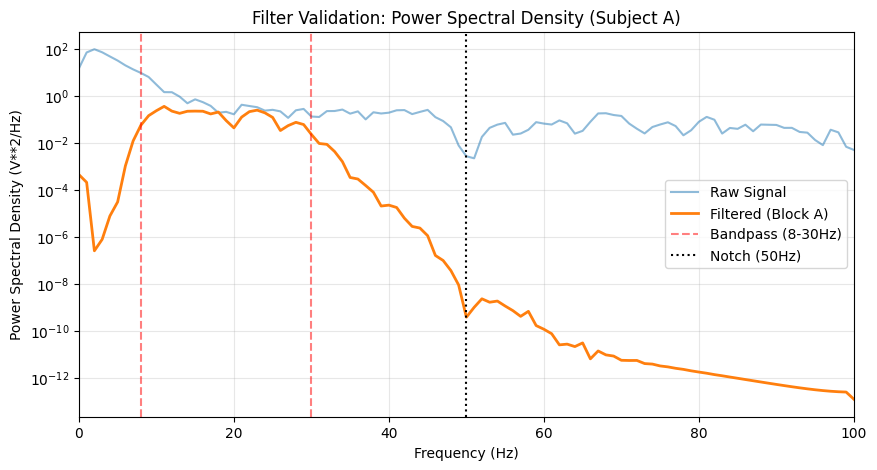

In [7]:
# Select the first subject for validation
first_subject = sorted(subject_data.keys())[0]
X_plot = subject_data[first_subject]['X']

# Select a random epoch and extract the first channel (Fp1)
idx_random     = np.random.randint(0, len(X_plot))
epoch_filtered = X_plot[idx_random, 0, :]  # Channel Fp1

# Load original raw data for comparison
sample_file = [f for f in glob.glob(os.path.join(DATASET_PATH, '*.mat'))
               if f'Subject{first_subject}' in os.path.basename(f)
               and ('CLA' in os.path.basename(f) or 'HaLT' in os.path.basename(f))
               and 'HFREQ' not in os.path.basename(f)][0]

raw_eeg, raw_markers, fs = load_kaya_mat(sample_file)

# Identify the first real motor imagery trial onset in the raw file
# to ensure the raw segment corresponds to the same type of neural activity
# as the filtered epoch (avoids comparing resting-state raw signal
# against a motor imagery filtered epoch)
diff_markers = np.diff(raw_markers, prepend=0)
onset_indices = np.where((raw_markers > 0) & (raw_markers <= 3) & (diff_markers != 0))[0]

if len(onset_indices) > 0:
    first_onset = onset_indices[0]
    start = first_onset + int(WINDOW_S[0] * fs)  # apply same 0.5s offset as epoching
    raw_signal = raw_eeg[start:start + 600, 0]   # Channel Fp1, same length as epoch
else:
    # Fallback: use the beginning of the recording if no valid onset is found
    raw_signal = raw_eeg[0:600, 0]
    print("[WARNING] No valid onset found, using beginning of recording as fallback.")

# Calculate Power Spectral Density using Welch's method
f_raw,  Pxx_raw  = welch(raw_signal,     fs=fs, nperseg=200)
f_filt, Pxx_filt = welch(epoch_filtered, fs=fs, nperseg=200)

# Plotting the spectral density comparison
plt.figure(figsize=(10, 5))
plt.semilogy(f_raw,  Pxx_raw,  label='Raw Signal', alpha=0.5)
plt.semilogy(f_filt, Pxx_filt, label='Filtered (Block A)', linewidth=2)
plt.title(f'Filter Validation: Power Spectral Density (Subject {first_subject})')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V**2/Hz)')
plt.axvline(8,  color='r', linestyle='--', alpha=0.5)
plt.axvline(30, color='r', linestyle='--', alpha=0.5, label='Bandpass (8-30Hz)')
plt.axvline(50, color='k', linestyle=':',             label='Notch (50Hz)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.show()

 ## Data Splitting and Normalization

To ensure the generalization capability of our model, we employ a Cross-Subject Split. By segregating data based on unique subject IDs rather than individual trials, we prevent the model from overfitting to subject-specific neural patterns, simulating a real-world Brain-Computer Interface (BCI) scenario.

**Splitting Strategy**

* Training Set (~70%): Used for parameter learning and gradient updates.
* Validation Set (~15%): Used for hyperparameter tuning and model selection.
* Test Set (~15%): Held-out data used exclusively for final model evaluation.


In [8]:
#  Cross-Subject Split 
n_total = len(all_subjects)
n_test  = max(1, round(n_total * 0.15))
n_val   = max(1, round(n_total * 0.15))
n_train = n_total - n_test - n_val

# Shuffle subjects to ensure random distribution
rng = np.random.RandomState(42)
shuffled = [str(s) for s in rng.permutation(all_subjects)]

TEST_SUBJECTS  = shuffled[-n_test:]
VAL_SUBJECTS   = shuffled[-(n_test + n_val):-n_test]
TRAIN_SUBJECTS = shuffled[:n_train]

print(f"Train subjects ({len(TRAIN_SUBJECTS)}) : {TRAIN_SUBJECTS}")
print(f"Val   subjects ({len(VAL_SUBJECTS)})   : {VAL_SUBJECTS}")
print(f"Test  subjects ({len(TEST_SUBJECTS)})  : {TEST_SUBJECTS}")

def _concat(subjects, data_dict):
    X = np.concatenate([data_dict[s]['X'] for s in subjects], axis=0)
    y = np.concatenate([data_dict[s]['y'] for s in subjects], axis=0)
    return X, y

X_train, y_train = _concat(TRAIN_SUBJECTS, subject_data)
X_val,   y_val   = _concat(VAL_SUBJECTS,   subject_data)
X_test,  y_test  = _concat(TEST_SUBJECTS,  subject_data)

# Shift labels (1-3 → 0-2)
y_train = y_train - 1
y_val   = y_val   - 1
y_test  = y_test  - 1


#  Channel-wise Normalization
# Statistics are calculated solely from the training set to prevent data leakage
mean = np.mean(X_train, axis=(0, 2), keepdims=True)
std  = np.std( X_train, axis=(0, 2), keepdims=True)

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Reshape for CNN input: (N, Channels, Time, 1)
X_train = X_train[..., np.newaxis]
X_val   = X_val[...,   np.newaxis]
X_test  = X_test[...,  np.newaxis]

print("\n--- DATA PREPARATION COMPLETE ---")
print(f"Training data   : {X_train.shape}  labels: {y_train.shape}")
print(f"Validation data : {X_val.shape}  labels: {y_val.shape}")
print(f"Test data       : {X_test.shape}  labels: {y_test.shape}")


print("Train class dist:", collections.Counter(y_train.tolist()))
print("Val class dist:  ", collections.Counter(y_val.tolist()))
print("Test class dist: ", collections.Counter(y_test.tolist()))

Train subjects (9) : ['L', 'J', 'A', 'I', 'F', 'C', 'B', 'M', 'E']
Val   subjects (2)   : ['H', 'K']
Test  subjects (2)  : ['D', 'G']

--- DATA PREPARATION COMPLETE ---
Training data   : (22873, 19, 600, 1)  labels: (22873,)
Validation data : (1897, 19, 600, 1)  labels: (1897,)
Test data       : (2393, 19, 600, 1)  labels: (2393,)
Train class dist: Counter({0: 7798, 1: 7778, 2: 7297})
Val class dist:   Counter({1: 639, 2: 631, 0: 627})
Test class dist:  Counter({0: 811, 2: 796, 1: 786})


Considering that we don't have a lot of subjects in our dataset, the classes seem to be well-balanced. 

# **Phase 3: Deep Learning Model Architectures**

In this phase, we explore the deep learning architectures used to classify motor imagery tasks. We compare a standard EEG-Net baseline, which is widely recognized for its efficiency in compact EEG feature extraction, against our proposed Multiscale Inception CNN.

Our custom architecture is designed to capture temporal and spatial patterns at varying scales simultaneously, which is crucial for the non-stationary nature of EEG data.

**Implementation Note:**
Both models are configured to process input tensors of shape (N, Channels, Time, 1). 

While EEG-Net relies on depthwise and separable convolutions to minimize parameter count, our Inception-based approach utilizes parallel convolutional branches to extract multi-resolution features, enhancing classification robustness across subjects.

## Phase 3A: EEG-Net Baseline Implementation

The EEG-Net architecture is a compact convolutional neural network designed specifically for EEG-based BCI tasks. Its primary strength lies in its use of depthwise and separable convolutions, which significantly reduce the number of trainable parameters while maintaining the ability to learn complex temporal and spatial feature representations.The implementation below follows the standard EEG-Net structure, tailored for our input dimensions $(19 \text{ channels}, 600 \text{ time points})$ and 3 classification categories.

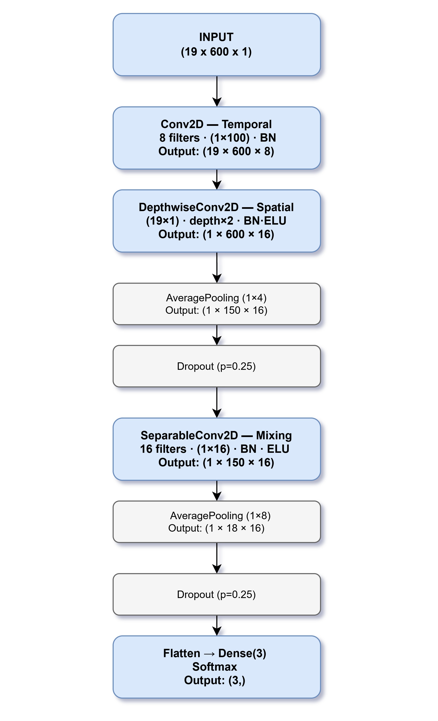

In [9]:
def build_eegnet_baseline(nb_classes=3, Chans=19, Samples=600, dropoutRate=0.25):

    """
    Builds the EEGNet architecture.
    
    Args:
        nb_classes (int): Number of target motor imagery classes.
        Chans (int): Number of EEG channels.
        Samples (int): Number of time points per epoch.
        dropoutRate (float): Dropout probability for regularization.
        
    Returns:
        model (tensorflow.keras.Model): Compiled EEGNet model.
    """
    

    # INPUT LAYER

    # Format matches your reshaped X_train: (Electrodes, Time, 1)
    input_layer = Input(shape=(Chans, Samples, 1))


    # BLOCK 1: Temporal Convolution

    # Purpose: Learns frequency filters over time. 
    # Trick: We use a kernel length of half the sampling rate (FS=200 -> length=100)
    # This allows it to capture frequencies at 2Hz and above.
    block1 = Conv2D(filters=8, kernel_size=(1, 100), padding='same', use_bias=False, kernel_regularizer=l2(0.001))(input_layer)
    block1 = BatchNormalization()(block1)


    # BLOCK 2: Spatial Filter

    # Purpose: Learns which electrodes are most important.
    # Trick: The kernel size (Chans, 1) looks across all electrodes at a single point in time.
    # We use 'max_norm' to prevent weights from blowing up, a standard practice for EEG.
    block2 = DepthwiseConv2D(kernel_size=(Chans, 1), use_bias=False, 
                             depth_multiplier=2, 
                             depthwise_constraint=max_norm(1.),
                            depthwise_regularizer=l2(0.001))(block1)
    block2 = BatchNormalization()(block2)
    block2 = Activation('elu')(block2) # ELU works better than ReLU for EEG
    
    # Compress the time dimension
    block2 = AveragePooling2D((1, 4))(block2)
    block2 = Dropout(dropoutRate)(block2)


    # BLOCK 3: Spatio-Temporal Mixing

    # Purpose: SeparableConv2D first applies depthwise spatial convolution, 
    # then pointwise (1x1) convolution to mix the features. It uses very few parameters.
    block3 = SeparableConv2D(filters=16, kernel_size=(1, 16), padding='same', use_bias=False,
                         depthwise_regularizer=l2(0.001),
                         pointwise_regularizer=l2(0.001))(block2)

    block3 = BatchNormalization()(block3)
    block3 = Activation('elu')(block3)
    
    # Compress time dimension again
    block3 = AveragePooling2D((1, 8))(block3)
    block3 = Dropout(dropoutRate)(block3)


    # CLASSIFICATION HEAD

    flatten = Flatten()(block3)
    
    # Output layer for 3 classes (Left Hand, Right Hand, Passive)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.25),kernel_regularizer=l2(0.001) )(flatten)
    softmax = Activation('softmax')(dense)

    # Create Model
    model = Model(inputs=input_layer, outputs=softmax)
    
    return model

# Instantiate the model
eegnet_model = build_eegnet_baseline(nb_classes=3, Chans=19, Samples=600)

# Compile the model
# Using Adam optimizer and sparse categorical crossentropy because labels are integers
eegnet_model.compile(loss='sparse_categorical_crossentropy', 
                     optimizer='adam', 
                     metrics=['accuracy'])

# Print the summary to check parameters
eegnet_model.summary()

I0000 00:00:1783010247.422179      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 19, 600, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 19, 600, 8)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 19, 600, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 600, 16)     │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 600, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 600, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 150, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 150, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 150, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 150, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 150, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 18, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 18, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           867 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,643 (10.32 KB)

 Trainable params: 2,563 (10.01 KB)

 Non-trainable params: 80 (320.00 B)

## Phase 3A: EEG-Net Model Training and Performance Evaluation

In this section, we train the model using our prepared training set and monitor its performance on the validation set. To ensure optimal convergence and prevent overfitting, we employ Early Stopping, which halts training if the validation loss does not improve over a specified number of epochs. Finally, we visualize the learning curves to assess the model's stability and generalization.

Starting Training of EEGNet Baseline...
Epoch 1/50


I0000 00:00:1783010257.571148     177 service.cc:152] XLA service 0x7b8f98033260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783010257.571190     177 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1783010257.999348     177 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1783010263.348946     177 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


358/358 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.4637 - loss: 1.0459 - val_accuracy: 0.5134 - val_loss: 1.0259
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6018 - loss: 0.8871 - val_accuracy: 0.5435 - val_loss: 1.0574
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6261 - loss: 0.8453 - val_accuracy: 0.5582 - val_loss: 1.0634
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6367 - loss: 0.8329 - val_accuracy: 0.5625 - val_loss: 1.0828
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6462 - loss: 0.8171 - val_accuracy: 0.5525 - val_loss: 1.0859
Epoch 6/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6488 - loss: 0.8100 - val_accuracy: 0.5598 - val_loss: 1.0554
Epoch 7/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6534 - loss: 0.8068 - val_accuracy: 0.5604 - val_loss: 1.0393
Epoch 8/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6552 - loss: 0.7983 - val_accuracy: 0.56

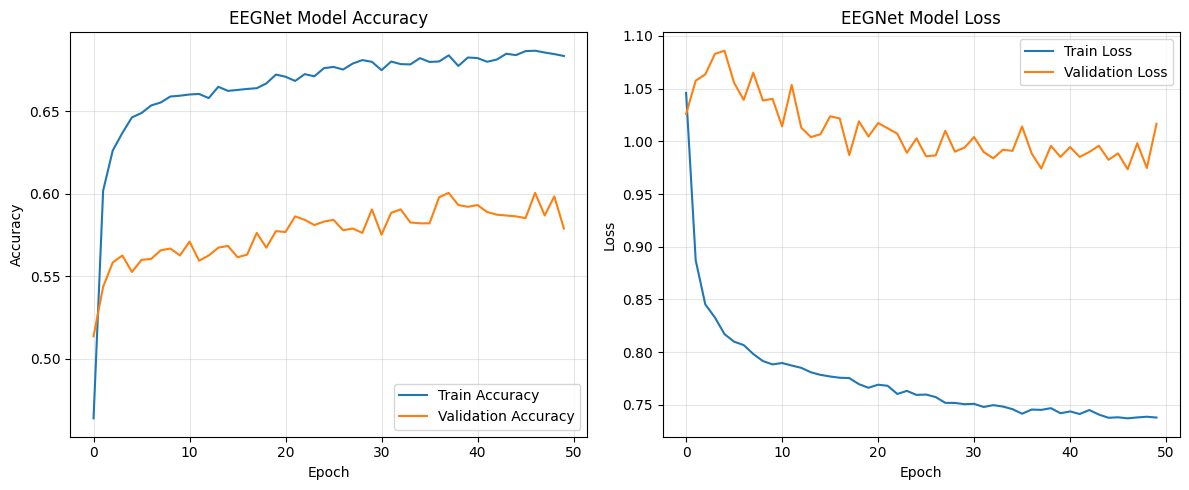

In [10]:
# Define Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)


# Train the Baseline Model
print("Starting Training of EEGNet Baseline...")
history = eegnet_model.fit(
    X_train, y_train,
    epochs=50,            # Maximum number of epochs
    batch_size=64,        # Number of samples per gradient update
    validation_data=(X_val, y_val),
    callbacks=[early_stop], 
    verbose=1             # Shows the progress bar
)

print("Training Complete!")

# Plot the Loss and Accuracy
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('EEGNet Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('EEGNet Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 3B: Multiscale Inception Implementation

The Multiscale Inception CNN represents our proposed contribution to the motor imagery classification pipeline. Unlike traditional models that rely on a fixed kernel size, the Inception module employs parallel convolutional branches with varying filter sizes. This design allows the network to capture temporal patterns at different resolutions—from fine-grained details to broader envelope contexts—within the 8-30Hz frequency band simultaneously.

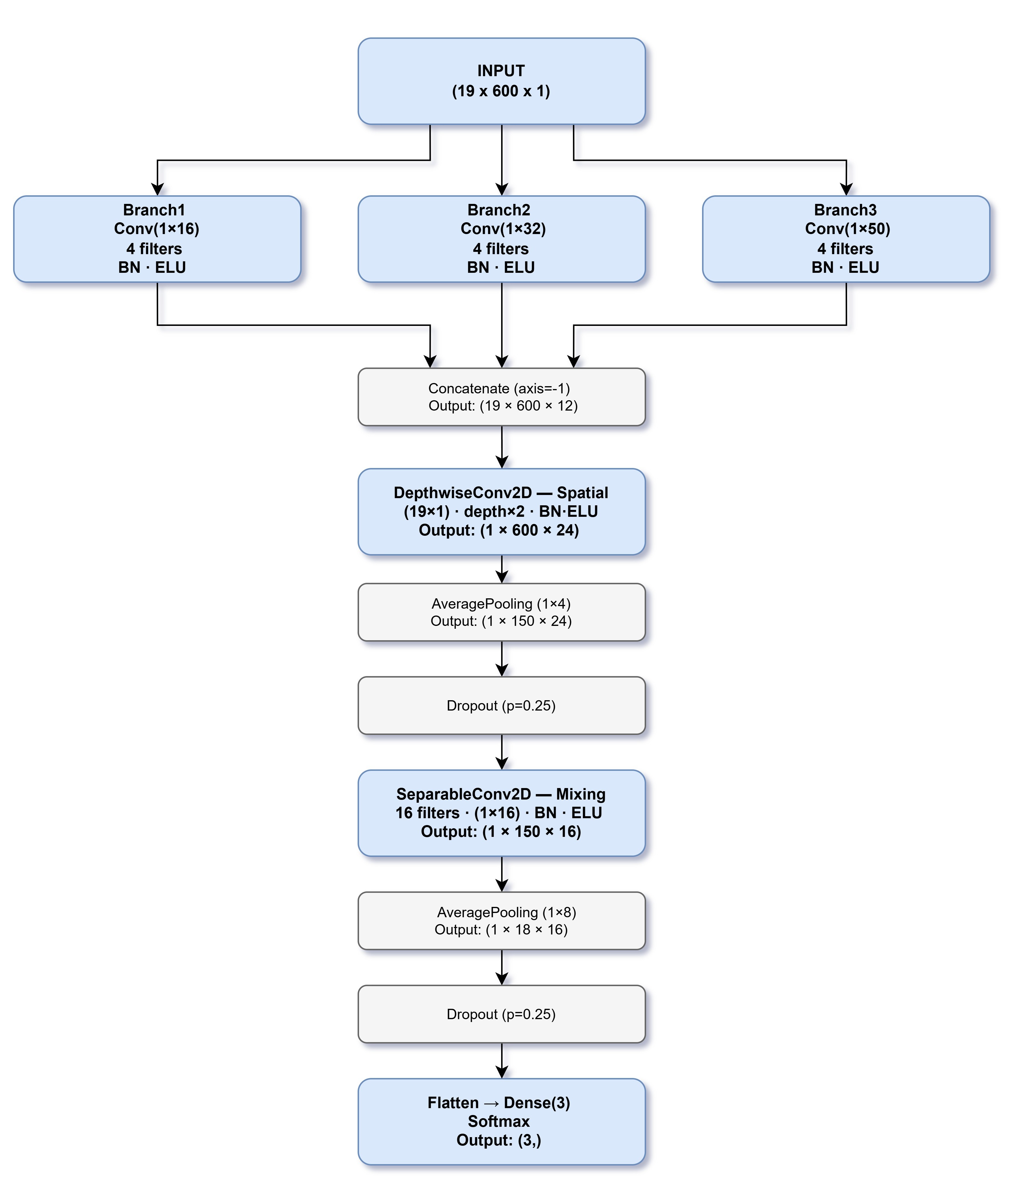

In [11]:
def build_multiscale_inception(nb_classes=3, Chans=19, Samples=600, dropoutRate=0.25):
    """
    Builds a Multiscale Inception CNN for EEG classification.
    
    Args:
        nb_classes (int): Number of target motor imagery classes.
        Chans (int): Number of EEG channels.
        Samples (int): Number of time points per epoch.
        dropoutRate (float): Dropout probability for regularization.
        
    Returns:
        model (tensorflow.keras.Model): Compiled Inception-based model.
    """
    # INPUT LAYER

    input_layer = Input(shape=(Chans, Samples, 1))

    # INCEPTION MODULE: Parallel Temporal Convolutions
 
    # Instead of one filter size, we use three in parallel to capture different frequencies.
    
    # Branch 1: Short kernel — fine-grained detail within the 8-30Hz passband 
    #(~80ms window, resolves down to ~12.5Hz)
    branch1 = Conv2D(filters=4, kernel_size=(1, 16), padding='same', use_bias=False, kernel_regularizer=l2(0.001))(input_layer)
    branch1 = BatchNormalization()(branch1)
    branch1 = Activation('elu')(branch1)

    # Branch 2: Medium kernel — captures mu-rhythm-scale oscillations 
    # (~160ms window, resolves down to ~6.25Hz)
    branch2 = Conv2D(filters=4, kernel_size=(1, 32), padding='same', use_bias=False, kernel_regularizer=l2(0.001))(input_layer)
    branch2 = BatchNormalization()(branch2)
    branch2 = Activation('elu')(branch2)

    # Branch 3: kernel size 50 chosen to capture slow envelope modulations 
    # within the passband; larger kernels (e.g. 128) are unnecessary given 
    # the 8-30Hz bandpass already applied in preprocessing.
    branch3 = Conv2D(filters=4, kernel_size=(1, 50), padding='same', use_bias=False, kernel_regularizer=l2(0.001))(input_layer)
    branch3 = BatchNormalization()(branch3)
    branch3 = Activation('elu')(branch3)

    # MERGE: Concatenate the branches along the filter axis (axis=-1)
    merged_temporal = Concatenate(axis=-1)([branch1, branch2, branch3])

    # SPATIAL FILTER

    # Learn electrode importance from the aggregated temporal features.
    spatial = DepthwiseConv2D(kernel_size=(Chans, 1), use_bias=False, 
                              depth_multiplier=2, 
                              depthwise_constraint=max_norm(1.),
                             depthwise_regularizer=l2(0.001))(merged_temporal)
    spatial = BatchNormalization()(spatial)
    spatial = Activation('elu')(spatial)
    
    # Compress the time dimension
    spatial = AveragePooling2D((1, 4))(spatial)
    spatial = Dropout(dropoutRate)(spatial)


    # MIXING LAYER

    # Mixes spatial and temporal features before classification.
    mix = SeparableConv2D(filters=16, kernel_size=(1, 16), padding='same', use_bias=False,
                      depthwise_regularizer=l2(0.001),
                      pointwise_regularizer=l2(0.001))(spatial)
    mix = BatchNormalization()(mix)
    mix = Activation('elu')(mix)
    mix = AveragePooling2D((1, 8))(mix)
    mix = Dropout(dropoutRate)(mix)


    # CLASSIFICATION HEAD

    flatten = Flatten()(mix)
    dense = Dense(nb_classes, kernel_constraint=max_norm(0.25), kernel_regularizer=l2(0.001))(flatten)
    softmax = Activation('softmax')(dense)

    return Model(inputs=input_layer, outputs=softmax)

# Instantiate the new architecture
inception_model = build_multiscale_inception(nb_classes=3, Chans=19, Samples=600)

# Compile
inception_model.compile(loss='sparse_categorical_crossentropy', 
                        optimizer='adam', 
                        metrics=['accuracy'])

# Check parameter count
inception_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 19, 600,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 19, 600,   │         64 │ input_layer_1[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 19, 600,   │        128 │ input_layer_1[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 19, 600,   │        200 │ input_layer_1[0]… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 600,   │         16 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 600,   │         16 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 19, 600,   │         16 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 19, 600,   │          0 │ batch_normalizat… │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 19, 600,   │          0 │ batch_normalizat… │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 19, 600,   │          0 │ batch_normalizat… │
│ (Activation)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 19, 600,   │          0 │ activation_3[0][… │
│ (Concatenate)       │ 12)               │            │ activation_4[0][… │
│                     │                   │            │ activation_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 1, 600,    │        456 │ concatenate[0][0] │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 600,    │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 1, 600,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_2 │ (None, 1, 150,    │          0 │ activation_6[0][… │
│ (AveragePooling2D)  │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 150,    │          0 │ average_pooling2… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,691 (10.51 KB)

 Trainable params: 2,587 (10.11 KB)

 Non-trainable params: 104 (416.00 B)

## Phase 3B: Multiscale Inception Training and Evaluation
With the Inception architecture defined, we now proceed to the training phase. By applying the same early stopping criteria and hyperparameter settings used for the EEG-Net baseline, we ensure a fair comparison of the two models' convergence behaviors and overall classification performance.

Starting Training of Multiscale Inception Model...
Epoch 1/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.4995 - loss: 1.0143 - val_accuracy: 0.5293 - val_loss: 1.0051
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6233 - loss: 0.8656 - val_accuracy: 0.5683 - val_loss: 1.0220
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6480 - loss: 0.8197 - val_accuracy: 0.5862 - val_loss: 0.9911
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6547 - loss: 0.7995 - val_accuracy: 0.5857 - val_loss: 0.9934
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6659 - loss: 0.7864 - val_accuracy: 0.6004 - val_loss: 0.9675
Epoch 6/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6683 - loss: 0.7735 - val_accuracy: 0.5894 - val_loss: 0.9739
Epoch 7/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6706 - loss: 0.7675 - val_accuracy: 0.6046 - val_loss: 0.9665
Epoch 8/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 7s 20

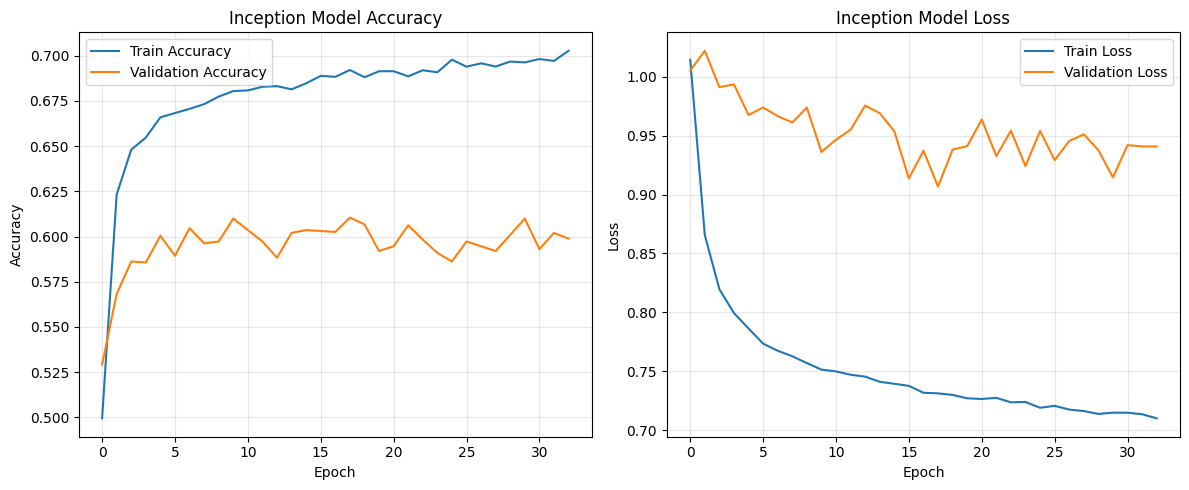

In [12]:
# Early Stopping (same as before)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the Original Architecture
print("Starting Training of Multiscale Inception Model...")
history_inception = inception_model.fit(
    X_train, y_train,
    epochs=50,            
    batch_size=64,        
    validation_data=(X_val, y_val),
    callbacks=[early_stop], 
    verbose=1             
)
print("Inception Training Complete!")

# Plot the Results
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_inception.history['accuracy'], label='Train Accuracy')
plt.plot(history_inception.history['val_accuracy'], label='Validation Accuracy')
plt.title('Inception Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_inception.history['loss'], label='Train Loss')
plt.plot(history_inception.history['val_loss'], label='Validation Loss')
plt.title('Inception Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 3C: Multi-Seed Stability Analysis

A single training run is inherently stochastic — results can vary due to random weight 
initialization, dropout masking, and batch ordering. To assess whether the performance 
gap between EEGNet and our Multiscale Inception is a **real architectural effect** or 
merely **random noise**, we re-train both models across 5 different random seeds.

The data split (X_train / X_val / X_test) remains fixed across all runs — only 
training-time randomness varies. This isolates the effect of weight initialization 
and stochastic regularization from the effect of data partitioning.

**Evaluation Protocol:**
- 5 seeds: `[42, 7, 123, 2024, 99]`
- Same Early Stopping criteria (`patience=15`, monitor=`val_loss`)
- Same hyperparameters for both architectures
- Final comparison via mean ± std of accuracy and Cohen's Kappa

The models trained with `seed=42` are preserved and reused in Phase 4 for the 
detailed per-class analysis, avoiding a redundant third training run

In [13]:
#  Multi-Seed Stability Check
# Re-trains both architectures across 5 seeds to check whether the
# accuracy/kappa gap between EEGNet and Inception is a real effect or just
# noise from weight init / dropout / batch order on a single run.
# Data split (X_train/X_val/X_test) stays fixed; only training-time randomness varies.

SEEDS = [42, 7, 123, 2024, 99]   # 5 seeds for a firmer stability estimate

results = []

for seed in SEEDS:
    print(f"\n{'='*60}\nSEED = {seed}\n{'='*60}")

    # Re-seed everything that affects weight init / dropout / shuffling
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    #  EEGNet 
    eegnet = build_eegnet_baseline(nb_classes=3, Chans=19, Samples=600)
    eegnet.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

    eegnet.fit(X_train, y_train, epochs=50, batch_size=64,
               validation_data=(X_val, y_val), callbacks=[es], verbose=0)
    y_pred = np.argmax(eegnet.predict(X_test, verbose=0), axis=1)
    acc_eegnet = np.mean(y_pred == y_test)
    kappa_eegnet = cohen_kappa_score(y_test, y_pred)
    print(f"EEGNet     -> acc={acc_eegnet:.4f}  kappa={kappa_eegnet:.4f}")

    #  Inception 
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)  # re-seed for fair comparison
    inception = build_multiscale_inception(nb_classes=3, Chans=19, Samples=600)
    inception.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    es2 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    
    inception.fit(X_train, y_train, epochs=50, batch_size=64,
                  validation_data=(X_val, y_val), callbacks=[es2], verbose=0)
    y_pred_inc = np.argmax(inception.predict(X_test, verbose=0), axis=1)
    acc_inception = np.mean(y_pred_inc == y_test)
    kappa_inception = cohen_kappa_score(y_test, y_pred_inc)
    print(f"Inception  -> acc={acc_inception:.4f}  kappa={kappa_inception:.4f}")

    results.append({
        'seed': seed,
        'acc_eegnet': acc_eegnet, 'kappa_eegnet': kappa_eegnet,
        'acc_inception': acc_inception, 'kappa_inception': kappa_inception,
    })

    # Keep the seed-42 models so Phase 4A/4B can reuse them directly below,
    # instead of retraining a 3rd time just for the detailed single-run analysis.
    if seed == 42:
        eegnet_model = eegnet
        inception_model = inception

#  Summary 
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("SUMMARY ACROSS SEEDS")
print("="*60)
print(results_df.to_string(index=False))

print(f"\nEEGNet     accuracy: {results_df.acc_eegnet.mean():.4f} ± {results_df.acc_eegnet.std():.4f}")
print(f"Inception  accuracy: {results_df.acc_inception.mean():.4f} ± {results_df.acc_inception.std():.4f}")
print(f"EEGNet     kappa:    {results_df.kappa_eegnet.mean():.4f} ± {results_df.kappa_eegnet.std():.4f}")
print(f"Inception  kappa:    {results_df.kappa_inception.mean():.4f} ± {results_df.kappa_inception.std():.4f}")

mean_gap = results_df.acc_inception.mean() - results_df.acc_eegnet.mean()
pooled_std = np.sqrt((results_df.acc_eegnet.std()**2 + results_df.acc_inception.std()**2) / 2)
print(f"\nMean accuracy gap (Inception - EEGNet): {mean_gap:.4f}")
print(f"Pooled std across seeds: {pooled_std:.4f}")
if pooled_std > 0 and abs(mean_gap) < pooled_std:
    print("NOTE: gap is smaller than run-to-run std — treat the ranking as inconclusive without more seeds.")
else:
    print("NOTE: gap exceeds run-to-run std — the ranking looks like a real effect, not noise.")


SEED = 42
EEGNet     -> acc=0.6975  kappa=0.5461
Inception  -> acc=0.6887  kappa=0.5327

SEED = 7
EEGNet     -> acc=0.7175  kappa=0.5762
Inception  -> acc=0.7062  kappa=0.5592

SEED = 123
EEGNet     -> acc=0.7079  kappa=0.5620
Inception  -> acc=0.7066  kappa=0.5600

SEED = 2024
EEGNet     -> acc=0.6916  kappa=0.5377
Inception  -> acc=0.6490  kappa=0.4747

SEED = 99
EEGNet     -> acc=0.6795  kappa=0.5201
Inception  -> acc=0.7192  kappa=0.5789

SUMMARY ACROSS SEEDS
 seed  acc_eegnet  kappa_eegnet  acc_inception  kappa_inception
   42    0.697451      0.546123       0.688675         0.532745
    7    0.717509      0.576183       0.706226         0.559247
  123    0.707898      0.561963       0.706644         0.560041
 2024    0.691601      0.537719       0.648976         0.474678
   99    0.679482      0.520054       0.719181         0.578900

EEGNet     accuracy: 0.6988 ± 0.0147
Inception  accuracy: 0.6939 ± 0.0274
EEGNet     kappa:    0.5484 ± 0.0217
Inception  kappa:    0.5411 ± 0.040

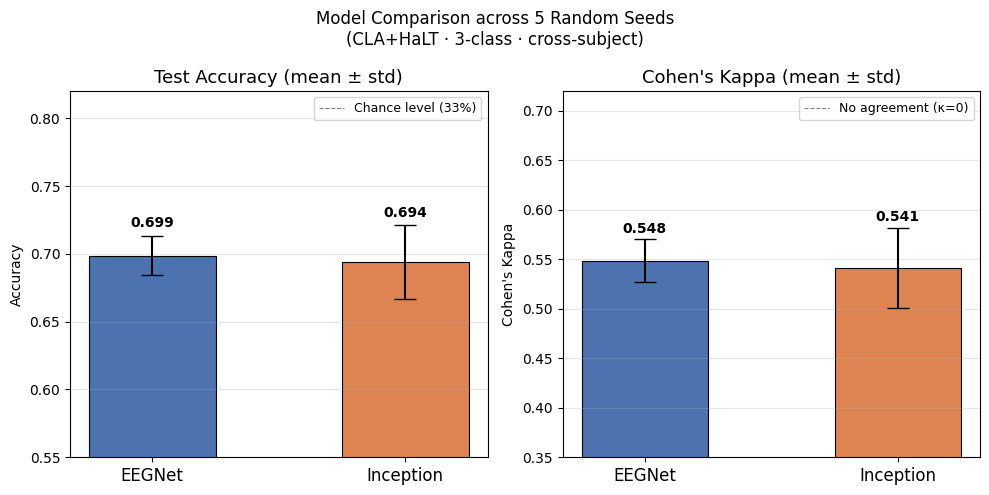

Gap (-0.0048) < pooled std (0.0220) → inconclusive


In [14]:
#  Bar Chart with Error Bars: Model Comparison across Seeds 

models = ['EEGNet', 'Inception']

acc_means  = [results_df.acc_eegnet.mean(),      results_df.acc_inception.mean()]
acc_stds   = [results_df.acc_eegnet.std(),        results_df.acc_inception.std()]
kappa_means = [results_df.kappa_eegnet.mean(),    results_df.kappa_inception.mean()]
kappa_stds  = [results_df.kappa_eegnet.std(),     results_df.kappa_inception.std()]

x = np.arange(len(models))
width = 0.5

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

#  Accuracy 
bars1 = ax1.bar(x, acc_means, width, yerr=acc_stds,
                capsize=8, color=['#4C72B0', '#DD8452'],
                edgecolor='black', linewidth=0.8)
ax1.set_title('Test Accuracy (mean ± std)', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=12)
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.55, 0.82)
ax1.axhline(1/3, color='gray', linestyle='--', linewidth=0.8, label='Chance level (33%)')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
for bar, mean, std in zip(bars1, acc_means, acc_stds):
    ax1.text(bar.get_x() + bar.get_width()/2, mean + std + 0.004,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

#  Kappa 
bars2 = ax2.bar(x, kappa_means, width, yerr=kappa_stds,
                capsize=8, color=['#4C72B0', '#DD8452'],
                edgecolor='black', linewidth=0.8)
ax2.set_title("Cohen's Kappa (mean ± std)", fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=12)
ax2.set_ylabel("Cohen's Kappa")
ax2.set_ylim(0.35, 0.72)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='No agreement (κ=0)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
for bar, mean, std in zip(bars2, kappa_means, kappa_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, mean + std + 0.004,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle(f'Model Comparison across {len(SEEDS)} Random Seeds\n'
             f'(CLA+HaLT · 3-class · cross-subject)',
             fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison_seeds.pdf', bbox_inches='tight', dpi=150)
plt.show()

print(f"Gap ({mean_gap:+.4f}) {'< ' if abs(mean_gap) < pooled_std else '>= '}"
      f"pooled std ({pooled_std:.4f}) → "
      f"{'inconclusive' if abs(mean_gap) < pooled_std else 'real effect'}")

# **Phase 4: Comparative Evaluation**

In this final phase, we perform a rigorous side-by-side performance analysis of our two models: the EEG-Net Baseline and our Multiscale Inception CNN.

To determine the effectiveness of the proposed architecture, we evaluate the models across four key dimensions:

* Predictive Accuracy: Quantifying overall classification performance.
* Confusion Patterns: Identifying if the models struggle with specific classes (e.g., distinguishing between Left Hand, Right Hand and Passive).
* Computational Complexity: Assessing the trade-off between model performance and real-time viability (inference time and memory footprint).
* Latent Feature Representation: Visualizing the internal feature space using t-SNE to observe how well each architecture separates the different motor imagery classes.

This comprehensive evaluation provides the empirical evidence needed to validate the architectural improvements made in our proposed design.

## Phase 4A: EEG-Net Comparative Evaluation

In this final evaluation phase, we perform a rigorous performance analysis of the EEG-Net Baseline. This includes computing predictive accuracy, assessing confusion patterns, evaluating computational complexity (inference time and memory usage), and visualizing the latent feature space using t-SNE. This set of metrics provides a comprehensive understanding of how effectively the model discriminates between the three motor imagery classes.

Generating predictions on the test set for EEGNet Baseline...
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Final Test Accuracy: 0.6975
Cohen's Kappa Score: 0.5461

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.81      0.75       811
           1       0.65      0.80      0.72       786
           2       0.80      0.49      0.61       796

    accuracy                           0.70      2393
   macro avg       0.72      0.70      0.69      2393
weighted avg       0.72      0.70      0.69      2393



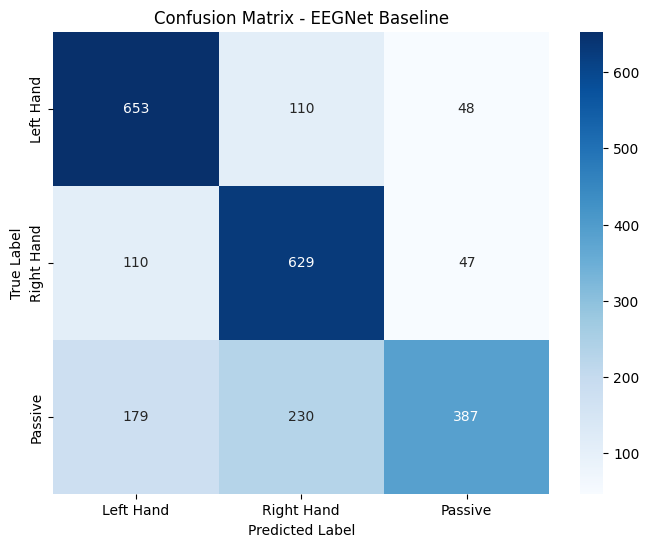


--- Complexity Analysis ---
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total Inference Time (Test Set): 0.6059 seconds
Inference Time per Epoch: 0.2532 milliseconds
Total Parameters: 2643
Estimated Model Weights Size: 10.32 KB

Extracting features from the test set for t-SNE...
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Running t-SNE (this might take a minute or two)...


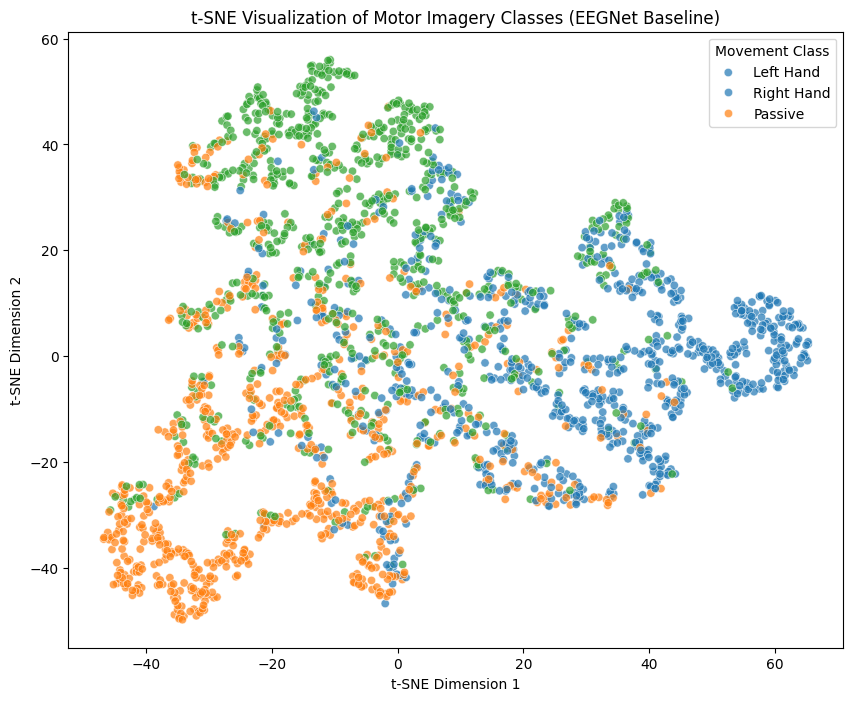

In [15]:
# Here below Predictions & Metrics, Confusion Matrix, Complexity Analysis and t-SNE Visualization for EEGNet baseline model

# Predictions & Metrics 
print("Generating predictions on the test set for EEGNet Baseline...")
y_pred_probs_eegnet = eegnet_model.predict(X_test)
y_pred_eegnet = np.argmax(y_pred_probs_eegnet, axis=1)

accuracy_eegnet = np.mean(y_pred_eegnet == y_test)
kappa_eegnet = cohen_kappa_score(y_test, y_pred_eegnet)

print(f"Final Test Accuracy: {accuracy_eegnet:.4f}")
print(f"Cohen's Kappa Score: {kappa_eegnet:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_eegnet))

# Confusion Matrix 
class_names = ['Left Hand', 'Right Hand', 'Passive']
cm_eegnet = confusion_matrix(y_test, y_pred_eegnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_eegnet, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EEGNet Baseline')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# Complexity Analysis 
print("\n--- Complexity Analysis ---")

# Inference Time Evaluation
start_time_eegnet = time.time()
_ = eegnet_model.predict(X_test)
end_time_eegnet = time.time()

total_time_eegnet = end_time_eegnet - start_time_eegnet
time_per_sample_eegnet = total_time_eegnet / len(X_test)

print(f"Total Inference Time (Test Set): {total_time_eegnet:.4f} seconds")
print(f"Inference Time per Epoch: {time_per_sample_eegnet * 1000:.4f} milliseconds")

# Memory Occupation (Parameter Count & Estimated Size)
total_params_eegnet = eegnet_model.count_params()

# Assuming 32-bit floats (4 bytes per parameter)
memory_bytes_eegnet = total_params_eegnet * 4
memory_kb_eegnet = memory_bytes_eegnet / 1024

print(f"Total Parameters: {total_params_eegnet}")
print(f"Estimated Model Weights Size: {memory_kb_eegnet:.2f} KB")

# t-SNE Visualization 
feature_extractor_eegnet = Model(inputs=eegnet_model.inputs, 
                                 outputs=eegnet_model.layers[-2].output)

print("\nExtracting features from the test set for t-SNE...")
features_eegnet = feature_extractor_eegnet.predict(X_test)

print("Running t-SNE (this might take a minute or two)...")
tsne_eegnet = TSNE(n_components=2, random_state=42)
tsne_results_eegnet = tsne_eegnet.fit_transform(features_eegnet)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_results_eegnet[:, 0], 
    y=tsne_results_eegnet[:, 1],
    hue=y_test,
    palette=sns.color_palette("tab10", 3),
    legend="full",
    alpha=0.7
)

plt.title('t-SNE Visualization of Motor Imagery Classes (EEGNet Baseline)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Movement Class', labels=class_names)
plt.show()

## Phase 4B: Multiscale Inception Comparative Evaluation
Following the evaluation of our baseline, we perform an identical analysis on our proposed Multiscale Inception CNN. By generating the confusion matrix, measuring computational complexity, and visualizing the latent feature space, we can directly contrast how effectively the Inception architecture learns to distinguish between motor imagery classes compared to the EEG-Net standard.

Generating predictions on the test set...
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Final Test Accuracy: 0.6887
Cohen's Kappa Score: 0.5327

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.65      0.84      0.73       811
           1       0.65      0.80      0.72       786
           2       0.88      0.43      0.58       796

    accuracy                           0.69      2393
   macro avg       0.73      0.69      0.68      2393
weighted avg       0.73      0.69      0.68      2393



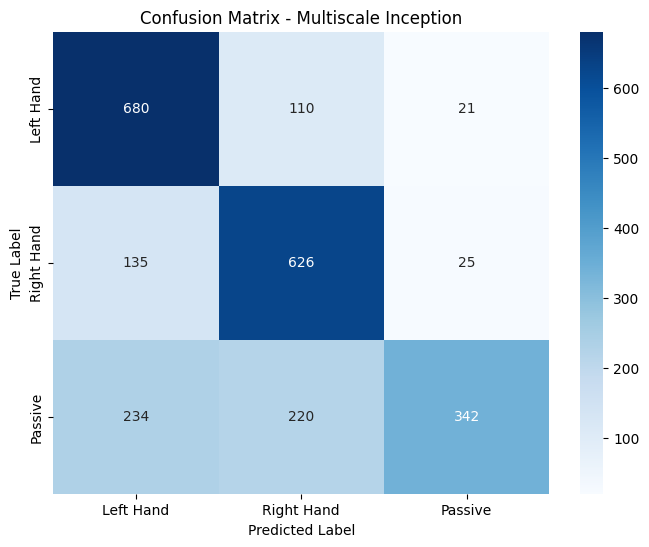


--- Complexity Analysis ---
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Total Inference Time (Test Set): 0.6261 seconds
Inference Time per Epoch: 0.2617 milliseconds
Total Parameters: 2691
Estimated Model Weights Size: 10.51 KB

Extracting features from the test set for t-SNE...
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Running t-SNE (this might take a minute or two)...


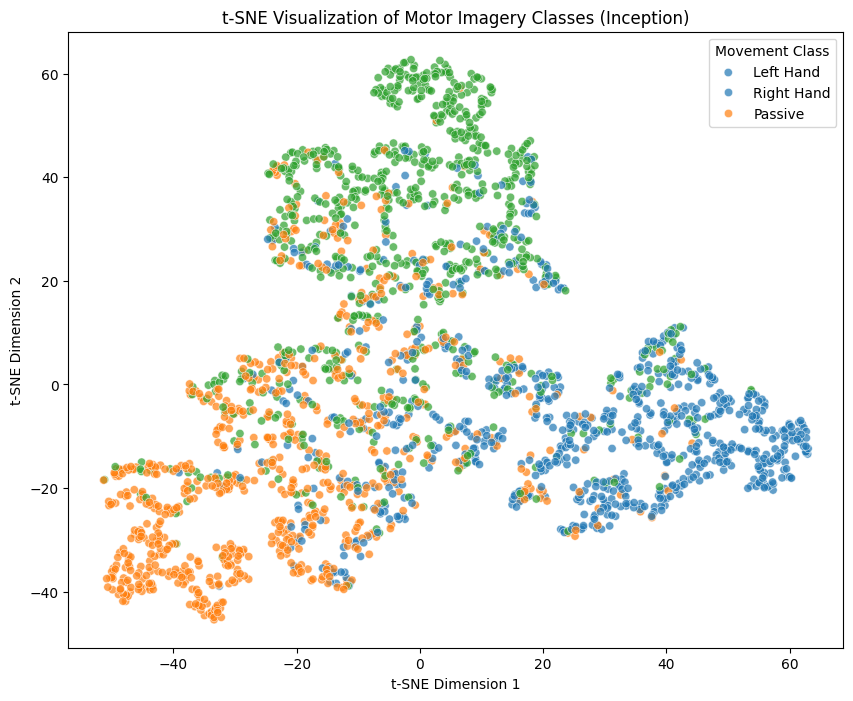

In [16]:
# Here below Predictions & Metrics, Confusion Matrix, Complexity Analysis and t-SNE Visualization for Multiscale Inception Model

# Predictions & Metrics
print("Generating predictions on the test set...")
y_pred_probs = inception_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

accuracy = np.mean(y_pred == y_test)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Cohen's Kappa Score: {kappa:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix 
class_names = ['Left Hand', 'Right Hand', 'Passive']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Multiscale Inception')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Complexity Analysis
print("\n--- Complexity Analysis ---")

# Inference Time Evaluation
start_time = time.time()
_ = inception_model.predict(X_test)
end_time = time.time()

total_time = end_time - start_time
time_per_sample = total_time / len(X_test)

print(f"Total Inference Time (Test Set): {total_time:.4f} seconds")
print(f"Inference Time per Epoch: {time_per_sample * 1000:.4f} milliseconds")

# Memory Occupation (Parameter Count & Estimated Size)
total_params = inception_model.count_params()

# Assuming 32-bit floats (4 bytes per parameter)
memory_bytes = total_params * 4
memory_kb = memory_bytes / 1024

print(f"Total Parameters: {total_params}")
print(f"Estimated Model Weights Size: {memory_kb:.2f} KB")

# t-SNE Visualization

feature_extractor = Model(inputs=inception_model.inputs, 
                          outputs=inception_model.layers[-2].output)

print("\nExtracting features from the test set for t-SNE...")
features = feature_extractor.predict(X_test)

print("Running t-SNE (this might take a minute or two)...")
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=tsne_results[:, 0], 
    y=tsne_results[:, 1],
    hue=y_test,
    palette=sns.color_palette("tab10", 3),
    legend="full",
    alpha=0.7
)

plt.title('t-SNE Visualization of Motor Imagery Classes (Inception)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Movement Class', labels=class_names)
plt.show()